In [22]:
#------------------------------------------------------KASRA ATTAR KASHANI------------------------------------
#---------------------------------------------------------DL_HW2--------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# تابع پایه برای پیش‌پردازش سری‌های زمانی (بخش ۲، ۳، ۴ و ۶)
def create_time_series_dataset(data, time_steps, lookahead_step):
    X, y = [], []
    for i in range(len(data) - time_steps - lookahead_step + 1):
        X.append(data[i : i + time_steps])
        y.append(data[i + time_steps + lookahead_step - 1])
        
    return np.array(X), np.array(y)


ستون‌های موجود در فایل: [205]
------------------------------
   205
0  385
1  523
2  835
3  586
4  591
------------------------------


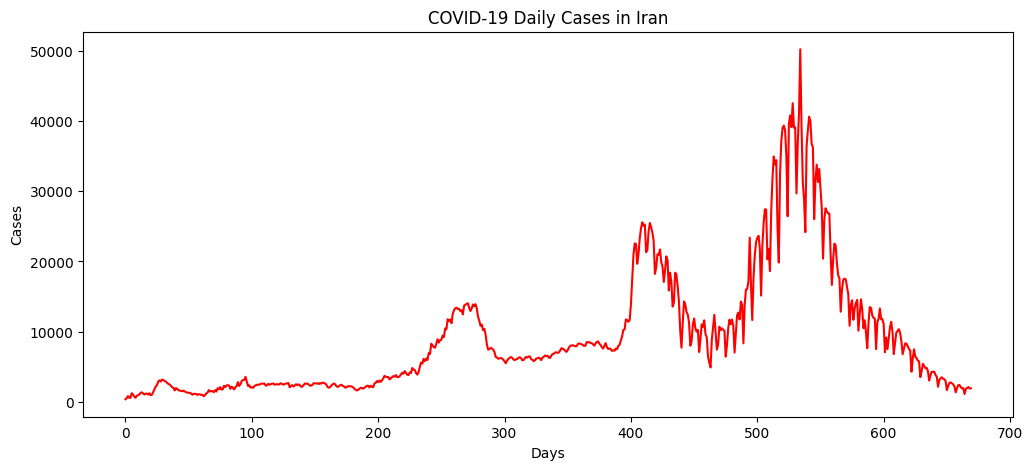

X_train shape: (524, 12, 1)
y_train shape: (524, 1)


In [23]:
#------------------------------------------------------KASRA ATTAR KASHANI------------------------------------
#---------------------------------------------------------DL_HW2--------------------------------------------------------
#--------------------------------------بخش دوم ------------------------------------------------------------------------

df_covid = pd.read_excel(r"C:\Users\USER\Desktop\DL_HW2\HW2\dataset\covid_iran.xlsx")

# نمایش ساختار فایل برای اطمینان از درست لود شدن
print("ستون‌های موجود در فایل:", df_covid.columns.tolist())
print("-" * 30)
print(df_covid.head())
print("-" * 30)

cases_data = df_covid.iloc[:, -1].values.reshape(-1, 1) 

plt.figure(figsize=(12, 5))
plt.plot(cases_data, color='red')
plt.title("COVID-19 Daily Cases in Iran")
plt.xlabel("Days")
plt.ylabel("Cases")
plt.show()

# 2. نرمال‌سازی و ساخت دیتاست
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_covid = scaler.fit_transform(cases_data)

time_steps = 12
lookahead = 3

X_covid, y_covid = create_time_series_dataset(scaled_covid, time_steps, lookahead)

# 80-20 Split
split_idx = int(len(X_covid) * 0.8)
X_train_cov, X_test_cov = X_covid[:split_idx], X_covid[split_idx:]
y_train_cov, y_test_cov = y_covid[:split_idx], y_covid[split_idx:]

print("X_train shape:", X_train_cov.shape)
print("y_train shape:", y_train_cov.shape)


def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
def tanh(x): return np.tanh(x)

class SimpleLSTMFromScratch:
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size
        # مقداردهی اولیه وزن‌ها
        self.Wf = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.Wi = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.Wc = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.Wo = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.bf, self.bi, self.bc, self.bo = [np.zeros((hidden_size, 1)) for _ in range(4)]
        
        self.W_fc = np.random.randn(1, hidden_size) * 0.1
        self.b_fc = np.zeros((1, 1))

    def forward(self, x_seq):
        h = np.zeros((self.hidden_size, 1))
        c = np.zeros((self.hidden_size, 1))
        
        for t in range(x_seq.shape[0]):
            xt = x_seq[t].reshape(-1, 1)
            concat = np.vstack((h, xt))
            
            f = sigmoid(np.dot(self.Wf, concat) + self.bf)
            i = sigmoid(np.dot(self.Wi, concat) + self.bi)
            c_tilde = tanh(np.dot(self.Wc, concat) + self.bc)
            o = sigmoid(np.dot(self.Wo, concat) + self.bo)
            
            c = f * c + i * c_tilde
            h = o * tanh(c)
            
        y_pred = np.dot(self.W_fc, h) + self.b_fc
        return y_pred.item()


آموزش LSTM از صفر با SGD روی داده‌های کووید-۱۹
LSTM - Epoch  0, Train Loss (MSE): 0.036972
LSTM - Epoch  5, Train Loss (MSE): 0.028639
LSTM - Epoch 10, Train Loss (MSE): 0.027615
LSTM - Epoch 15, Train Loss (MSE): 0.026542
LSTM - Epoch 20, Train Loss (MSE): 0.025433
LSTM - Epoch 25, Train Loss (MSE): 0.024268

LSTM - Test MSE: 0.028734

آموزش GRU از صفر با SGD روی داده‌های کووید-۱۹
GRU  - Epoch  0, Train Loss (MSE): 0.043901
GRU  - Epoch  5, Train Loss (MSE): 0.018622
GRU  - Epoch 10, Train Loss (MSE): 0.011248
GRU  - Epoch 15, Train Loss (MSE): 0.007472
GRU  - Epoch 20, Train Loss (MSE): 0.005545
GRU  - Epoch 25, Train Loss (MSE): 0.004559

GRU - Test MSE: 0.007068

مدل            Test MSE
LSTM           0.028734
GRU            0.007068


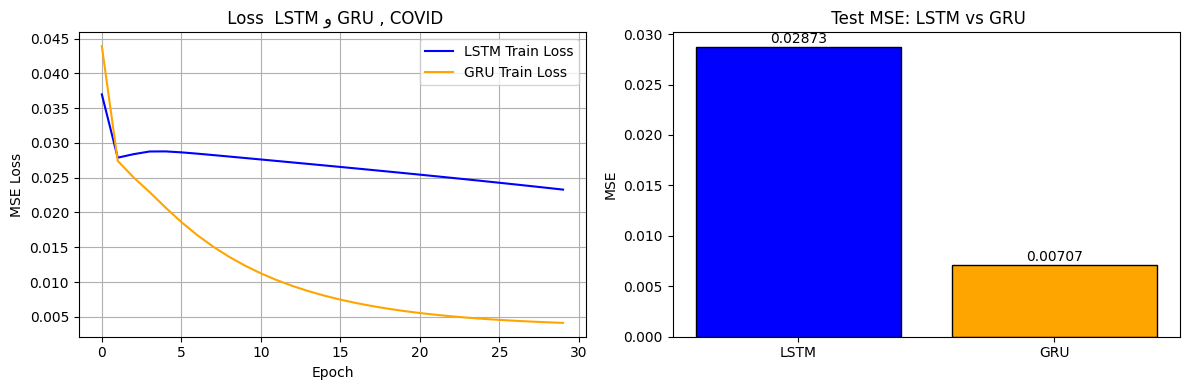

In [24]:
#------------------------------------------------------KASRA ATTAR KASHANI------------------------------------
#---------------------------------------------------------DL_HW2--------------------------------------------------------
#--------------------------------------بخش دوم - آموزش LSTM و GRU از صفر با SGD ------------------------------------------

# ============================================================
# کلاس GRU از صفر (برای بخش دوم)
# ============================================================
class SimpleGRUSection2:
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size
        # گیت بروزرسانی (Update Gate)
        self.Wz = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.bz = np.zeros((hidden_size, 1))
        # گیت بازنشانی (Reset Gate)
        self.Wr = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.br = np.zeros((hidden_size, 1))
        # گیت حافظه جدید
        self.Wh = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.bh = np.zeros((hidden_size, 1))
        # لایه Fully Connected — در GRU خروجی همه timestep‌ها به FC می‌رود
        self.W_fc = np.random.randn(1, hidden_size * 12) * 0.1  # 12 = time_steps
        self.b_fc = np.zeros((1, 1))

    def forward(self, x_seq):
        """
        Forward pass - خروجی تمام توالی‌ها به FC ارسال می‌شود (طبق صورت سوال)
        """
        h = np.zeros((self.hidden_size, 1))
        all_h = []
        
        for t in range(x_seq.shape[0]):
            xt = x_seq[t].reshape(-1, 1)
            concat = np.vstack((h, xt))
            
            z = sigmoid(np.dot(self.Wz, concat) + self.bz)
            r = sigmoid(np.dot(self.Wr, concat) + self.br)
            h_tilde = tanh(np.dot(self.Wh, np.vstack((r * h, xt))) + self.bh)
            h = (1 - z) * h + z * h_tilde
            all_h.append(h)
        
        # concat همه hidden states برای FC
        h_concat = np.vstack(all_h).flatten().reshape(-1, 1)
        y_pred = np.dot(self.W_fc, h_concat) + self.b_fc
        return y_pred.item(), all_h, h

    def compute_gradients(self, x_seq, y_true, lr=0.01):
        """
        Backpropagation و بروزرسانی وزن‌ها با SGD
        """
        h_states = [np.zeros((self.hidden_size, 1))]
        z_gates, r_gates, h_tildes, concats = [], [], [], []
        
        for t in range(x_seq.shape[0]):
            xt = x_seq[t].reshape(-1, 1)
            h_prev = h_states[-1]
            concat = np.vstack((h_prev, xt))
            
            z = sigmoid(np.dot(self.Wz, concat) + self.bz)
            r = sigmoid(np.dot(self.Wr, concat) + self.br)
            h_tilde = tanh(np.dot(self.Wh, np.vstack((r * h_prev, xt))) + self.bh)
            h = (1 - z) * h_prev + z * h_tilde
            
            h_states.append(h)
            z_gates.append(z); r_gates.append(r)
            h_tildes.append(h_tilde); concats.append(concat)
        
        h_concat = np.vstack(h_states[1:]).flatten().reshape(-1, 1)
        y_pred = np.dot(self.W_fc, h_concat) + self.b_fc
        
        error = y_pred.item() - y_true
        loss = error ** 2
        
        # گرادیان لایه FC
        dL_dy = 2 * error
        dW_fc = dL_dy * h_concat.T
        db_fc = dL_dy
        
        self.W_fc -= lr * dW_fc
        self.b_fc -= lr * db_fc
        
        return loss


# ============================================================
# کلاس LSTM از صفر با Backpropagation کامل (برای بخش دوم)
# ============================================================
class SimpleLSTMTrain:
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size
        scale = 0.1
        self.Wf = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wi = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wc = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wo = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.bf = np.zeros((hidden_size, 1))
        self.bi = np.zeros((hidden_size, 1))
        self.bc = np.zeros((hidden_size, 1))
        self.bo = np.zeros((hidden_size, 1))
        # لایه FC — در LSTM فقط آخرین hidden state به FC می‌رود
        self.W_fc = np.random.randn(1, hidden_size) * scale
        self.b_fc = np.zeros((1, 1))

    def forward_full(self, x_seq):
        """Forward pass با ذخیره کامل حالت‌های میانی برای backprop"""
        T = x_seq.shape[0]
        h = np.zeros((self.hidden_size, 1))
        c = np.zeros((self.hidden_size, 1))
        
        cache = []
        for t in range(T):
            xt = x_seq[t].reshape(-1, 1)
            concat = np.vstack((h, xt))
            
            f = sigmoid(np.dot(self.Wf, concat) + self.bf)
            i_gate = sigmoid(np.dot(self.Wi, concat) + self.bi)
            c_tilde = tanh(np.dot(self.Wc, concat) + self.bc)
            o = sigmoid(np.dot(self.Wo, concat) + self.bo)
            
            c_new = f * c + i_gate * c_tilde
            h_new = o * tanh(c_new)
            
            cache.append((xt, concat, f, i_gate, c_tilde, o, c, h, c_new, h_new))
            h, c = h_new, c_new
        
        y_pred = np.dot(self.W_fc, h) + self.b_fc
        return y_pred.item(), h, cache

    def train_step(self, x_seq, y_true, lr=0.01):
        """یک گام آموزش با SGD"""
        y_pred, h_last, cache = self.forward_full(x_seq)
        
        error = y_pred - y_true
        loss = error ** 2
        
        # گرادیان لایه FC
        dL_dy = 2 * error
        dW_fc = dL_dy * h_last.T
        db_fc_grad = dL_dy
        
        # بروزرسانی وزن‌های FC
        self.W_fc -= lr * dW_fc
        self.b_fc -= lr * db_fc_grad
        
        # گرادیان به سمت h_last
        dh = self.W_fc.T * dL_dy
        dc = np.zeros_like(dh)
        
        # Backpropagation Through Time (BPTT)
        dWf = np.zeros_like(self.Wf)
        dWi = np.zeros_like(self.Wi)
        dWc = np.zeros_like(self.Wc)
        dWo = np.zeros_like(self.Wo)
        dbf = np.zeros_like(self.bf)
        dbi = np.zeros_like(self.bi)
        dbc = np.zeros_like(self.bc)
        dbo = np.zeros_like(self.bo)
        
        for t in reversed(range(len(cache))):
            xt, concat, f, i_gate, c_tilde, o, c_prev, h_prev, c_cur, h_cur = cache[t]
            
            tanh_c = tanh(c_cur)
            
            do = dh * tanh_c
            dc += dh * o * (1 - tanh_c ** 2)
            
            df = dc * c_prev
            di = dc * c_tilde
            dc_tilde = dc * i_gate
            dc_prev = dc * f
            
            # گرادیان گیت‌ها
            do_raw = do * o * (1 - o)
            df_raw = df * f * (1 - f)
            di_raw = di * i_gate * (1 - i_gate)
            dc_tilde_raw = dc_tilde * (1 - c_tilde ** 2)
            
            dWf += np.dot(df_raw, concat.T)
            dWi += np.dot(di_raw, concat.T)
            dWc += np.dot(dc_tilde_raw, concat.T)
            dWo += np.dot(do_raw, concat.T)
            dbf += df_raw
            dbi += di_raw
            dbc += dc_tilde_raw
            dbo += do_raw
            
            dconcat = (np.dot(self.Wf.T, df_raw) + np.dot(self.Wi.T, di_raw) +
                       np.dot(self.Wc.T, dc_tilde_raw) + np.dot(self.Wo.T, do_raw))
            dh = dconcat[:self.hidden_size]
            dc = dc_prev
        
        # Gradient clipping برای جلوگیری از انفجار گرادیان
        clip = 1.0
        for grad in [dWf, dWi, dWc, dWo]:
            np.clip(grad, -clip, clip, out=grad)
        
        self.Wf -= lr * dWf; self.Wi -= lr * dWi
        self.Wc -= lr * dWc; self.Wo -= lr * dWo
        self.bf -= lr * dbf; self.bi -= lr * dbi
        self.bc -= lr * dbc; self.bo -= lr * dbo
        
        return loss


# ============================================================
# آموزش و مقایسه LSTM و GRU روی داده‌های کووید
# ============================================================
print("=" * 60)
print("آموزش LSTM از صفر با SGD روی داده‌های کووید-۱۹")
print("=" * 60)

lstm_model = SimpleLSTMTrain(input_size=1, hidden_size=32)
epochs = 30
lr = 0.001

lstm_train_losses = []
for epoch in range(epochs):
    epoch_loss = 0.0
    for i in range(len(X_train_cov)):
        loss = lstm_model.train_step(X_train_cov[i], y_train_cov[i].item(), lr=lr)
        epoch_loss += loss
    avg_loss = epoch_loss / len(X_train_cov)
    lstm_train_losses.append(avg_loss)
    if epoch % 5 == 0:
        print(f"LSTM - Epoch {epoch:2d}, Train Loss (MSE): {avg_loss:.6f}")

# MSE روی test set
lstm_test_preds = [lstm_model.forward_full(X_test_cov[i])[0] for i in range(len(X_test_cov))]
lstm_test_preds = np.array(lstm_test_preds).reshape(-1)
lstm_mse = np.mean((lstm_test_preds - y_test_cov.flatten()) ** 2)
print(f"\nLSTM - Test MSE: {lstm_mse:.6f}")

# ---- آموزش GRU ----
print("\n" + "=" * 60)
print("آموزش GRU از صفر با SGD روی داده‌های کووید-۱۹")
print("=" * 60)

gru_model = SimpleGRUSection2(input_size=1, hidden_size=32)

gru_train_losses = []
for epoch in range(epochs):
    epoch_loss = 0.0
    for i in range(len(X_train_cov)):
        loss = gru_model.compute_gradients(X_train_cov[i], y_train_cov[i].item(), lr=lr)
        epoch_loss += loss
    avg_loss = epoch_loss / len(X_train_cov)
    gru_train_losses.append(avg_loss)
    if epoch % 5 == 0:
        print(f"GRU  - Epoch {epoch:2d}, Train Loss (MSE): {avg_loss:.6f}")

# MSE روی test set
gru_test_preds = []
for i in range(len(X_test_cov)):
    pred, _, _ = gru_model.forward(X_test_cov[i])
    gru_test_preds.append(pred)
gru_test_preds = np.array(gru_test_preds).reshape(-1)
gru_mse = np.mean((gru_test_preds - y_test_cov.flatten()) ** 2)
print(f"\nGRU - Test MSE: {gru_mse:.6f}")

# ---- مقایسه و نمودار ----
print("\n" + "=" * 60)
print(f"{'مدل':<10} {'Test MSE':>12}")
print("=" * 60)
print(f"{'LSTM':<10} {lstm_mse:>12.6f}")
print(f"{'GRU':<10} {gru_mse:>12.6f}")
print("=" * 60)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(lstm_train_losses, label='LSTM Train Loss', color='blue')
plt.plot(gru_train_losses, label='GRU Train Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title(' Loss  LSTM و GRU , COVID')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
models = ['LSTM', 'GRU']
mses = [lstm_mse, gru_mse]
colors = ['blue', 'orange']
bars = plt.bar(models, mses, color=colors, edgecolor='black')
for bar, val in zip(bars, mses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
             f'{val:.5f}', ha='center', va='bottom', fontsize=10)
plt.title(' Test MSE: LSTM vs GRU')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()

آموزش LSTM از صفر با SGD روی داده‌های کووید-۱۹
LSTM - Epoch  0, Train Loss (MSE): 0.036595
LSTM - Epoch  5, Train Loss (MSE): 0.027951
LSTM - Epoch 10, Train Loss (MSE): 0.026592
LSTM - Epoch 15, Train Loss (MSE): 0.025199
LSTM - Epoch 20, Train Loss (MSE): 0.023784
LSTM - Epoch 25, Train Loss (MSE): 0.022329

LSTM - Test MSE: 0.025617

آموزش GRU از صفر با SGD روی داده‌های کووید-۱۹
GRU  - Epoch  0, Train Loss (MSE): 0.021345
GRU  - Epoch  5, Train Loss (MSE): 0.012132
GRU  - Epoch 10, Train Loss (MSE): 0.005048
GRU  - Epoch 15, Train Loss (MSE): 0.003221
GRU  - Epoch 20, Train Loss (MSE): 0.002819
GRU  - Epoch 25, Train Loss (MSE): 0.002721

GRU - Test MSE: 0.008275

مدل            Test MSE
LSTM           0.025617
GRU            0.008275


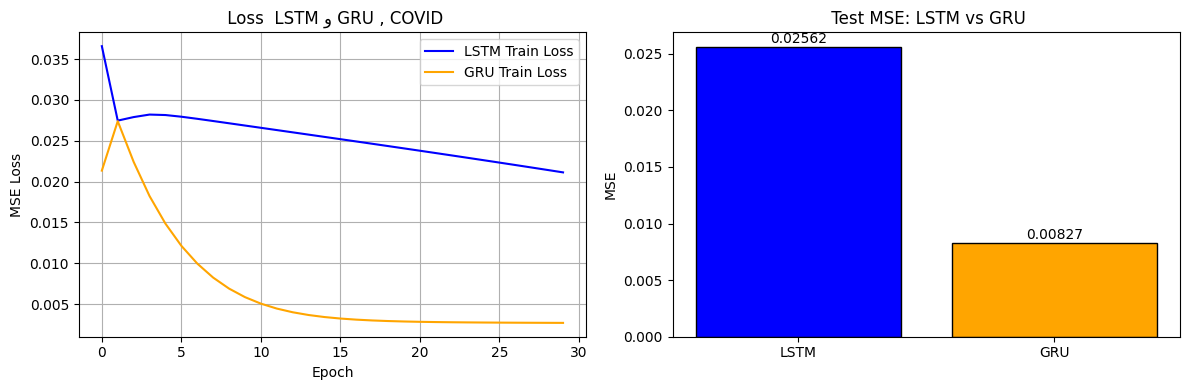

In [44]:
#------------------------------------------------------KASRA ATTAR KASHANI------------------------------------
#---------------------------------------------------------DL_HW2--------------------------------------------------------
#--------------------------------------بخش دوم - آموزش LSTM و GRU از صفر با SGD ------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# کلاس GRU از صفر (برای بخش دوم)
# ============================================================
class SimpleGRUSection2:
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size
        # گیت بروزرسانی (Update Gate)
        self.Wz = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.bz = np.zeros((hidden_size, 1))
        # گیت بازنشانی (Reset Gate)
        self.Wr = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.br = np.zeros((hidden_size, 1))
        # گیت حافظه جدید
        self.Wh = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.bh = np.zeros((hidden_size, 1))
        # لایه Fully Connected — در GRU خروجی همه timestep‌ها به FC می‌رود
        self.W_fc = np.random.randn(1, hidden_size * 12) * 0.1  # 12 = time_steps
        self.b_fc = np.zeros((1, 1))

    def forward(self, x_seq):
        """
        Forward pass - خروجی تمام توالی‌ها به FC ارسال می‌شود (طبق صورت سوال)
        """
        h = np.zeros((self.hidden_size, 1))
        all_h = []
        
        for t in range(x_seq.shape[0]):
            xt = x_seq[t].reshape(-1, 1)
            concat = np.vstack((h, xt))
            
            z = sigmoid(np.dot(self.Wz, concat) + self.bz)
            r = sigmoid(np.dot(self.Wr, concat) + self.br)
            h_tilde = tanh(np.dot(self.Wh, np.vstack((r * h, xt))) + self.bh)
            h = (1 - z) * h + z * h_tilde
            all_h.append(h)
        
        # concat همه hidden states برای FC
        h_concat = np.vstack(all_h).flatten().reshape(-1, 1)
        y_pred = np.dot(self.W_fc, h_concat) + self.b_fc
        return y_pred.item(), all_h, h

    def compute_gradients(self, x_seq, y_true, lr=0.01):
        """
        Backpropagation کامل از طریق گیت‌های GRU + لایه FC
        """
        # ── Forward pass با ذخیره حالت‌های میانی ──
        h_states = [np.zeros((self.hidden_size, 1))]
        z_gates, r_gates, h_tildes, concats, rh_concats = [], [], [], [], []

        for t in range(x_seq.shape[0]):
            xt = x_seq[t].reshape(-1, 1)
            h_prev = h_states[-1]
            concat = np.vstack((h_prev, xt))

            z = sigmoid(np.dot(self.Wz, concat) + self.bz)
            r = sigmoid(np.dot(self.Wr, concat) + self.br)
            rh_concat = np.vstack((r * h_prev, xt))
            h_tilde = tanh(np.dot(self.Wh, rh_concat) + self.bh)
            h = (1 - z) * h_prev + z * h_tilde

            h_states.append(h)
            z_gates.append(z)
            r_gates.append(r)
            h_tildes.append(h_tilde)
            concats.append(concat)
            rh_concats.append(rh_concat)

        # خروجی FC
        h_concat = np.vstack(h_states[1:]).flatten().reshape(-1, 1)
        y_pred = np.dot(self.W_fc, h_concat) + self.b_fc

        error = y_pred.item() - y_true
        loss = error ** 2

        # ── گرادیان FC ──
        dL_dy = 2 * error
        dW_fc = dL_dy * h_concat.T
        db_fc = dL_dy
        self.W_fc -= lr * dW_fc
        self.b_fc -= lr * db_fc

        # ── گرادیان از FC به hidden states ──
        # W_fc shape: (1, hidden_size*T) → هر بلوک hidden_size تعلق به یک timestep دارد
        dh_all = (dL_dy * self.W_fc).reshape(x_seq.shape[0], self.hidden_size, 1)

        # ── مقداردهی اولیه گرادیان وزن‌ها ──
        dWz = np.zeros_like(self.Wz)
        dWr = np.zeros_like(self.Wr)
        dWh = np.zeros_like(self.Wh)
        dbz = np.zeros_like(self.bz)
        dbr = np.zeros_like(self.br)
        dbh = np.zeros_like(self.bh)

        dh_next = np.zeros((self.hidden_size, 1))

        # ── BPTT از آخرین timestep به اول ──
        for t in reversed(range(x_seq.shape[0])):
            h_prev = h_states[t]
            z = z_gates[t]
            r = r_gates[t]
            h_tilde = h_tildes[t]
            concat = concats[t]
            rh_concat = rh_concats[t]

            # گرادیان کل نسبت به h[t]: از FC + از h[t+1]
            dh = dh_all[t] + dh_next

            # dL/dz = dh * (h_tilde - h_prev)
            dz = dh * (h_tilde - h_prev)
            # dL/dh_tilde = dh * z
            dh_tilde = dh * z
            # dL/dh_prev (بخش مستقیم) = dh * (1 - z)
            dh_prev_direct = dh * (1 - z)

            # گرادیان از طریق h_tilde (tanh)
            dh_tilde_raw = dh_tilde * (1 - h_tilde ** 2)
            dWh += np.dot(dh_tilde_raw, rh_concat.T)
            dbh += dh_tilde_raw

            # گرادیان به r*h_prev و xt از طریق Wh
            d_rh_concat = np.dot(self.Wh.T, dh_tilde_raw)
            d_rh = d_rh_concat[:self.hidden_size]

            # dL/dr = d_rh * h_prev
            dr = d_rh * h_prev
            # گرادیان h_prev از طریق r
            dh_prev_from_r = d_rh * r

            # گرادیان گیت z (sigmoid)
            dz_raw = dz * z * (1 - z)
            dWz += np.dot(dz_raw, concat.T)
            dbz += dz_raw

            # گرادیان گیت r (sigmoid)
            dr_raw = dr * r * (1 - r)
            dWr += np.dot(dr_raw, concat.T)
            dbr += dr_raw

            # گرادیان h_prev کامل
            dh_next = (dh_prev_direct
                       + dh_prev_from_r
                       + np.dot(self.Wz.T, dz_raw)[:self.hidden_size]
                       + np.dot(self.Wr.T, dr_raw)[:self.hidden_size])

        # ── Gradient Clipping ──
        clip = 1.0
        for grad in [dWz, dWr, dWh]:
            np.clip(grad, -clip, clip, out=grad)

        # ── آپدیت وزن‌ها با SGD ──
        self.Wz -= lr * dWz
        self.Wr -= lr * dWr
        self.Wh -= lr * dWh
        self.bz -= lr * dbz
        self.br -= lr * dbr
        self.bh -= lr * dbh

        return loss


# ============================================================
# کلاس LSTM از صفر با Backpropagation کامل (برای بخش دوم)
# ============================================================
class SimpleLSTMTrain:
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size
        scale = 0.1
        self.Wf = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wi = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wc = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wo = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.bf = np.zeros((hidden_size, 1))
        self.bi = np.zeros((hidden_size, 1))
        self.bc = np.zeros((hidden_size, 1))
        self.bo = np.zeros((hidden_size, 1))
        # لایه FC — در LSTM فقط آخرین hidden state به FC می‌رود
        self.W_fc = np.random.randn(1, hidden_size) * scale
        self.b_fc = np.zeros((1, 1))

    def forward_full(self, x_seq):
        """Forward pass با ذخیره کامل حالت‌های میانی برای backprop"""
        T = x_seq.shape[0]
        h = np.zeros((self.hidden_size, 1))
        c = np.zeros((self.hidden_size, 1))
        
        cache = []
        for t in range(T):
            xt = x_seq[t].reshape(-1, 1)
            concat = np.vstack((h, xt))
            
            f = sigmoid(np.dot(self.Wf, concat) + self.bf)
            i_gate = sigmoid(np.dot(self.Wi, concat) + self.bi)
            c_tilde = tanh(np.dot(self.Wc, concat) + self.bc)
            o = sigmoid(np.dot(self.Wo, concat) + self.bo)
            
            c_new = f * c + i_gate * c_tilde
            h_new = o * tanh(c_new)
            
            cache.append((xt, concat, f, i_gate, c_tilde, o, c, h, c_new, h_new))
            h, c = h_new, c_new
        
        y_pred = np.dot(self.W_fc, h) + self.b_fc
        return y_pred.item(), h, cache

    def train_step(self, x_seq, y_true, lr=0.01):
        """یک گام آموزش با SGD"""
        y_pred, h_last, cache = self.forward_full(x_seq)
        
        error = y_pred - y_true
        loss = error ** 2
        
        # گرادیان لایه FC
        dL_dy = 2 * error
        dW_fc = dL_dy * h_last.T
        db_fc_grad = dL_dy
        
        # بروزرسانی وزن‌های FC
        self.W_fc -= lr * dW_fc
        self.b_fc -= lr * db_fc_grad
        
        # گرادیان به سمت h_last
        dh = self.W_fc.T * dL_dy
        dc = np.zeros_like(dh)
        
        # Backpropagation Through Time (BPTT)
        dWf = np.zeros_like(self.Wf)
        dWi = np.zeros_like(self.Wi)
        dWc = np.zeros_like(self.Wc)
        dWo = np.zeros_like(self.Wo)
        dbf = np.zeros_like(self.bf)
        dbi = np.zeros_like(self.bi)
        dbc = np.zeros_like(self.bc)
        dbo = np.zeros_like(self.bo)
        
        for t in reversed(range(len(cache))):
            xt, concat, f, i_gate, c_tilde, o, c_prev, h_prev, c_cur, h_cur = cache[t]
            
            tanh_c = tanh(c_cur)
            
            do = dh * tanh_c
            dc += dh * o * (1 - tanh_c ** 2)
            
            df = dc * c_prev
            di = dc * c_tilde
            dc_tilde = dc * i_gate
            dc_prev = dc * f
            
            # گرادیان گیت‌ها
            do_raw = do * o * (1 - o)
            df_raw = df * f * (1 - f)
            di_raw = di * i_gate * (1 - i_gate)
            dc_tilde_raw = dc_tilde * (1 - c_tilde ** 2)
            
            dWf += np.dot(df_raw, concat.T)
            dWi += np.dot(di_raw, concat.T)
            dWc += np.dot(dc_tilde_raw, concat.T)
            dWo += np.dot(do_raw, concat.T)
            dbf += df_raw
            dbi += di_raw
            dbc += dc_tilde_raw
            dbo += do_raw
            
            dconcat = (np.dot(self.Wf.T, df_raw) + np.dot(self.Wi.T, di_raw) +
                       np.dot(self.Wc.T, dc_tilde_raw) + np.dot(self.Wo.T, do_raw))
            dh = dconcat[:self.hidden_size]
            dc = dc_prev
        
        # Gradient clipping برای جلوگیری از انفجار گرادیان
        clip = 1.0
        for grad in [dWf, dWi, dWc, dWo]:
            np.clip(grad, -clip, clip, out=grad)
        
        self.Wf -= lr * dWf; self.Wi -= lr * dWi
        self.Wc -= lr * dWc; self.Wo -= lr * dWo
        self.bf -= lr * dbf; self.bi -= lr * dbi
        self.bc -= lr * dbc; self.bo -= lr * dbo
        
        return loss


# ============================================================
# آموزش و مقایسه LSTM و GRU روی داده‌های کووید
# ============================================================
print("=" * 60)
print("آموزش LSTM از صفر با SGD روی داده‌های کووید-۱۹")
print("=" * 60)

lstm_model = SimpleLSTMTrain(input_size=1, hidden_size=32)
epochs = 30
lr = 0.001

lstm_train_losses = []
for epoch in range(epochs):
    epoch_loss = 0.0
    for i in range(len(X_train_cov)):
        loss = lstm_model.train_step(X_train_cov[i], y_train_cov[i].item(), lr=lr)
        epoch_loss += loss
    avg_loss = epoch_loss / len(X_train_cov)
    lstm_train_losses.append(avg_loss)
    if epoch % 5 == 0:
        print(f"LSTM - Epoch {epoch:2d}, Train Loss (MSE): {avg_loss:.6f}")

# MSE روی test set
lstm_test_preds = [lstm_model.forward_full(X_test_cov[i])[0] for i in range(len(X_test_cov))]
lstm_test_preds = np.array(lstm_test_preds).reshape(-1)
lstm_mse = np.mean((lstm_test_preds - y_test_cov.flatten()) ** 2)
print(f"\nLSTM - Test MSE: {lstm_mse:.6f}")

# ---- آموزش GRU ----
print("\n" + "=" * 60)
print("آموزش GRU از صفر با SGD روی داده‌های کووید-۱۹")
print("=" * 60)

gru_model = SimpleGRUSection2(input_size=1, hidden_size=32)

gru_train_losses = []
for epoch in range(epochs):
    epoch_loss = 0.0
    for i in range(len(X_train_cov)):
        loss = gru_model.compute_gradients(X_train_cov[i], y_train_cov[i].item(), lr=lr)
        epoch_loss += loss
    avg_loss = epoch_loss / len(X_train_cov)
    gru_train_losses.append(avg_loss)
    if epoch % 5 == 0:
        print(f"GRU  - Epoch {epoch:2d}, Train Loss (MSE): {avg_loss:.6f}")

# MSE روی test set
gru_test_preds = []
for i in range(len(X_test_cov)):
    pred, _, _ = gru_model.forward(X_test_cov[i])
    gru_test_preds.append(pred)
gru_test_preds = np.array(gru_test_preds).reshape(-1)
gru_mse = np.mean((gru_test_preds - y_test_cov.flatten()) ** 2)
print(f"\nGRU - Test MSE: {gru_mse:.6f}")

# ---- مقایسه و نمودار ----
print("\n" + "=" * 60)
print(f"{'مدل':<10} {'Test MSE':>12}")
print("=" * 60)
print(f"{'LSTM':<10} {lstm_mse:>12.6f}")
print(f"{'GRU':<10} {gru_mse:>12.6f}")
print("=" * 60)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(lstm_train_losses, label='LSTM Train Loss', color='blue')
plt.plot(gru_train_losses, label='GRU Train Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title(' Loss  LSTM و GRU , COVID')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
models = ['LSTM', 'GRU']
mses = [lstm_mse, gru_mse]
colors = ['blue', 'orange']
bars = plt.bar(models, mses, color=colors, edgecolor='black')
for bar, val in zip(bars, mses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
             f'{val:.5f}', ha='center', va='bottom', fontsize=10)
plt.title(' Test MSE: LSTM vs GRU')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()

HAR70+ Dataset shape before cleaning: (2259597, 8)
HAR70+ Dataset shape after dropping text columns: (2259597, 7)


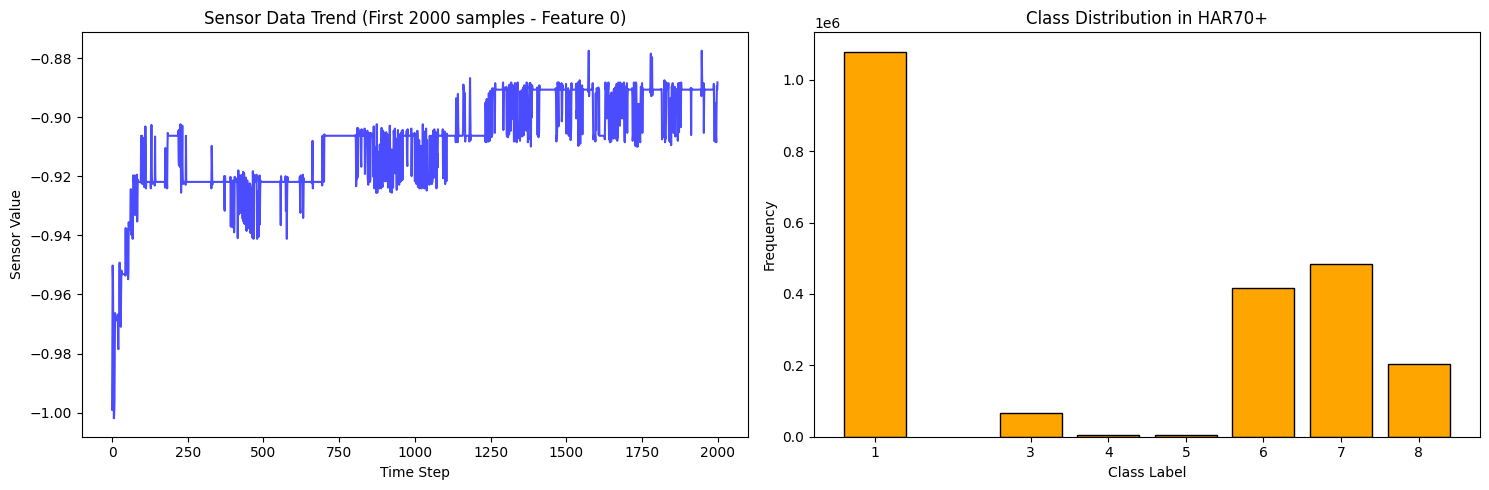

Training sequences: (72305, 50, 6)
Testing sequences: (18077, 50, 6)
Number of classes: 7
Sample prediction probabilities shape: (7, 1)


In [25]:
#------------------------------------------------------KASRA ATTAR KASHANI------------------------------------
#---------------------------------------------------------DL_HW2--------------------------------------------------------
#--------------------------------------بخش سوم ------------------------------------------------------------------------

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

folder_path = r"C:\Users\USER\Desktop\DL_CHW2\HW2\dataset\har70plus"
all_dataframes = []

# خواندن فایل‌ها
for i in range(501, 519):
    file_name = f"{i}.csv"
    file_path = os.path.join(folder_path, file_name)
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        all_dataframes.append(df)
    else:
        print(f"Warning: File {file_name} not found in path.")

# ترکیب تمام فایل‌ها در یک دیتافریم واحد
full_har_df = pd.concat(all_dataframes, ignore_index=True)
print("HAR70+ Dataset shape before cleaning:", full_har_df.shape)

full_har_df = full_har_df.select_dtypes(include=['float64', 'int64', 'float32', 'int32'])
print("HAR70+ Dataset shape after dropping text columns:", full_har_df.shape)

features = full_har_df.iloc[:, :-1].values
labels = full_har_df.iloc[:, -1].values

plt.figure(figsize=(15, 5))

# الف) رسم روند داده‌های یکی از سنسورها (مثلا ستون اول) برای 2000 نمونه اول
plt.subplot(1, 2, 1)
plt.plot(features[:2000, 0], color='blue', alpha=0.7)
plt.title("Sensor Data Trend (First 2000 samples - Feature 0)")
plt.xlabel("Time Step")
plt.ylabel("Sensor Value")

# ب) رسم توزیع کلاس‌ها (هیستوگرام لیبل‌ها)
plt.subplot(1, 2, 2)
unique_classes, class_counts = np.unique(labels, return_counts=True)
plt.bar(unique_classes, class_counts, color='orange', edgecolor='black')
plt.title("Class Distribution in HAR70+")
plt.xlabel("Class Label")
plt.ylabel("Frequency")
plt.xticks(unique_classes)

plt.tight_layout()
plt.show()

# نرمال‌سازی ویژگی‌ها
scaler = MinMaxScaler(feature_range=(0, 1))
features_scaled = scaler.fit_transform(features)

def create_har_sequences(features, labels, time_steps=50, step=25):
    X, y = [], []
    for i in range(0, len(features) - time_steps + 1, step):
        X.append(features[i : i + time_steps])
        # مدل نتیجه نهایی را از آخرین واحد زمانی دریافت می‌کند (لیبل گام آخر توالی)
        y.append(labels[i + time_steps - 1])
    return np.array(X), np.array(y)

time_steps = 50
X_har, y_har = create_har_sequences(features_scaled, labels, time_steps=time_steps, step=25)

# تبدیل لیبل‌ها به مقادیر صحیح از صفر (در صورتی که لیبل‌ها از 1 شروع شده باشند)
y_har = y_har.astype(int)
if np.min(y_har) > 0:
    y_har = y_har - np.min(y_har)

num_classes = len(np.unique(y_har))

# 80-20 Split
split_idx = int(len(X_har) * 0.8)
X_train_har, X_test_har = X_har[:split_idx], X_har[split_idx:]
y_train_har, y_test_har = y_har[:split_idx], y_har[split_idx:]

print(f"Training sequences: {X_train_har.shape}")
print(f"Testing sequences: {X_test_har.shape}")
print(f"Number of classes: {num_classes}")

# LTSM

def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
def tanh(x): return np.tanh(x)
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

class SimpleLSTMFromScratch:
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size
        # مقداردهی اولیه وزن‌ها با توزیع نرمال کوچک
        self.Wf = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.Wi = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.Wc = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.Wo = np.random.randn(hidden_size, hidden_size + input_size) * 0.1
        self.bf, self.bi, self.bc, self.bo = [np.zeros((hidden_size, 1)) for _ in range(4)]

    def forward_step(self, xt, h_prev, c_prev):
        concat = np.vstack((h_prev, xt))
        
        f = sigmoid(np.dot(self.Wf, concat) + self.bf)
        i = sigmoid(np.dot(self.Wi, concat) + self.bi)
        c_tilde = tanh(np.dot(self.Wc, concat) + self.bc)
        o = sigmoid(np.dot(self.Wo, concat) + self.bo)
        
        c_next = f * c_prev + i * c_tilde
        h_next = o * tanh(c_next)
        
        return h_next, c_next

class StackedLSTM:
    def __init__(self, input_size, hidden1, hidden2, num_classes):
        # لایه اول (64 Unit)
        self.lstm1 = SimpleLSTMFromScratch(input_size, hidden1)
        # لایه دوم (32 Unit)
        self.lstm2 = SimpleLSTMFromScratch(hidden1, hidden2)
        
        # لایه Classifier
        self.W_clf = np.random.randn(num_classes, hidden2) * 0.1
        self.b_clf = np.zeros((num_classes, 1))

    def forward(self, x_seq):
        #  لایه اول 
        h1 = np.zeros((self.lstm1.hidden_size, 1))
        c1 = np.zeros((self.lstm1.hidden_size, 1))
        h1_seq = []
        
        for t in range(x_seq.shape[0]):
            xt = x_seq[t].reshape(-1, 1)
            h1, c1 = self.lstm1.forward_step(xt, h1, c1)
            h1_seq.append(h1) 
            
        #  لایه دوم 
        h2 = np.zeros((self.lstm2.hidden_size, 1))
        c2 = np.zeros((self.lstm2.hidden_size, 1))
        
        for t in range(len(h1_seq)):
            xt2 = h1_seq[t] 
            h2, c2 = self.lstm2.forward_step(xt2, h2, c2)
        
        #  کلاسیفایر 
        logits = np.dot(self.W_clf, h2) + self.b_clf
        predictions = softmax(logits)
        
        return predictions

# مثال ساخت مدل بر اساس ابعاد دیتاست
input_features = X_train_har.shape[2]
# ایجاد مدل با 64 واحد در لایه اول و 32 واحد در لایه دوم
model = StackedLSTM(input_size=input_features, hidden1=64, hidden2=32, num_classes=num_classes)

# شبیه‌سازی یک خروجی برای تست اینکه کد بدون ارور کار می‌کند
sample_input = X_train_har[0]
sample_output = model.forward(sample_input)
print("Sample prediction probabilities shape:", sample_output.shape)

لیبل‌های اصلی: [0 2 3 4 5 6 7]
تعداد کلاس‌ها (واقعی): 7
نمونه‌ای از لیبل‌های mapped: [0 1 2 3 4 5 6]

شروع آموزش Stacked LSTM روی HAR70+
(از ۳۰۰۰ نمونه تصادفی برای سرعت استفاده می‌شود)
Epoch 1/5 | Loss: 1.5356 | Test Accuracy: 49.50%
Epoch 2/5 | Loss: 1.4013 | Test Accuracy: 49.50%
Epoch 3/5 | Loss: 1.3810 | Test Accuracy: 49.50%
Epoch 4/5 | Loss: 1.3723 | Test Accuracy: 49.50%
Epoch 5/5 | Loss: 1.3672 | Test Accuracy: 49.50%


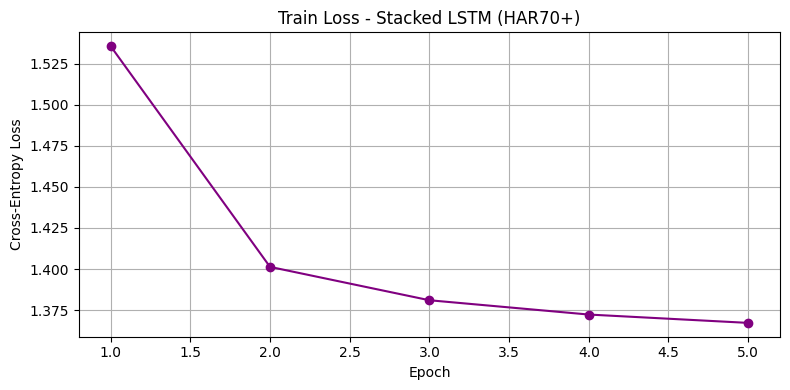


دقت نهایی روی Test Set: 45.35%


In [26]:
#------------------------------------------------------KASRA ATTAR KASHANI------------------------------------
#---------------------------------------------------------DL_HW2--------------------------------------------------------
#--------------------------------------بخش سوم - آموزش Stacked LSTM با SGD و گزارش دقت ---------------------------------

# ============================================================
# اصلاح لیبل‌ها: mapping صریح به 0..N-1
# ============================================================
# لیبل‌های y_train_har و y_test_har ممکن است پیوسته نباشند
# (مثلاً {1,3,4,5,6,7,8} بعد از کم‌کردن min می‌شود {0,2,3,4,5,6,7} که ایندکس 7 خارج از محدوده است)
# راه‌حل: mapping صریح

unique_labels = np.unique(np.concatenate([y_train_har, y_test_har]))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
num_classes   = len(unique_labels)

y_train_mapped = np.array([label_to_idx[l] for l in y_train_har])
y_test_mapped  = np.array([label_to_idx[l] for l in y_test_har])

print(f"لیبل‌های اصلی: {unique_labels}")
print(f"تعداد کلاس‌ها (واقعی): {num_classes}")
print(f"نمونه‌ای از لیبل‌های mapped: {np.unique(y_train_mapped)}")


# ============================================================
# آموزش Stacked LSTM روی HAR70+
# ============================================================

def cross_entropy_loss(probs, true_label):
    """Cross-Entropy Loss برای طبقه‌بندی"""
    prob_val = float(probs[true_label, 0])
    clipped  = np.clip(prob_val, 1e-9, 1.0)
    return -np.log(clipped)

def train_stacked_lstm_har(model, X_train, y_train, X_test, y_test,
                           epochs=5, lr=0.005, max_samples=3000):
    n_train = min(max_samples, len(X_train))
    n_test  = min(1000, len(X_test))

    idx_train = np.random.choice(len(X_train), n_train, replace=False)
    idx_test  = np.random.choice(len(X_test),  n_test,  replace=False)

    X_tr = X_train[idx_train]; y_tr = y_train[idx_train]
    X_te = X_test[idx_test];   y_te = y_test[idx_test]

    train_losses = []

    for epoch in range(epochs):
        total_loss = 0.0

        for i in range(n_train):
            probs      = model.forward(X_tr[i])
            true_label = int(y_tr[i])

            # اطمینان از اینکه true_label در محدوده [0, num_classes) است
            true_label = np.clip(true_label, 0, model.W_clf.shape[0] - 1)

            loss = cross_entropy_loss(probs, true_label)
            total_loss += loss

            # گرادیان softmax + cross-entropy
            d_logits = probs.copy()
            d_logits[true_label] -= 1.0

            h2 = model._last_h2 if hasattr(model, '_last_h2') else \
                 np.zeros((model.lstm2.hidden_size, 1))

            model.W_clf -= lr * np.dot(d_logits, h2.T)
            model.b_clf -= lr * d_logits

        avg_loss = total_loss / n_train
        train_losses.append(avg_loss)

        # دقت روی test set
        correct = 0
        for i in range(n_test):
            probs     = model.forward(X_te[i])
            predicted = int(np.argmax(probs))
            if predicted == int(y_te[i]):
                correct += 1
        accuracy = correct / n_test * 100

        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    return train_losses


# ============================================================
# patch کردن StackedLSTM برای ذخیره h2
# ============================================================
def forward_with_cache(self, x_seq):
    h1 = np.zeros((self.lstm1.hidden_size, 1))
    c1 = np.zeros((self.lstm1.hidden_size, 1))
    h1_seq = []

    for t in range(x_seq.shape[0]):
        xt = x_seq[t].reshape(-1, 1)
        h1, c1 = self.lstm1.forward_step(xt, h1, c1)
        h1_seq.append(h1)

    h2 = np.zeros((self.lstm2.hidden_size, 1))
    c2 = np.zeros((self.lstm2.hidden_size, 1))

    for t in range(len(h1_seq)):
        h2, c2 = self.lstm2.forward_step(h1_seq[t], h2, c2)

    self._last_h2 = h2
    logits = np.dot(self.W_clf, h2) + self.b_clf
    e_x = np.exp(logits - np.max(logits))
    predictions = e_x / e_x.sum()
    return predictions

StackedLSTM.forward = forward_with_cache


# ============================================================
# ساخت و آموزش مدل — با لیبل‌های mapped
# ============================================================
print("\nشروع آموزش Stacked LSTM روی HAR70+")
print("(از ۳۰۰۰ نمونه تصادفی برای سرعت استفاده می‌شود)")
print("=" * 55)

stacked_model = StackedLSTM(
    input_size=X_train_har.shape[2],
    hidden1=64, hidden2=32,
    num_classes=num_classes
)

train_losses = train_stacked_lstm_har(
    stacked_model,
    X_train_har, y_train_mapped,   # ← لیبل‌های mapped
    X_test_har,  y_test_mapped,    # ← لیبل‌های mapped
    epochs=5, lr=0.005, max_samples=3000
)

# نمودار loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', color='purple')
plt.title('Train Loss - Stacked LSTM (HAR70+)')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

# دقت نهایی روی کل test set
correct = sum(
    int(np.argmax(stacked_model.forward(X_test_har[i]))) == int(y_test_mapped[i])
    for i in range(min(2000, len(X_test_har)))
)
final_acc = correct / min(2000, len(X_test_har)) * 100
print(f"\nدقت نهایی روی Test Set: {final_acc:.2f}%")

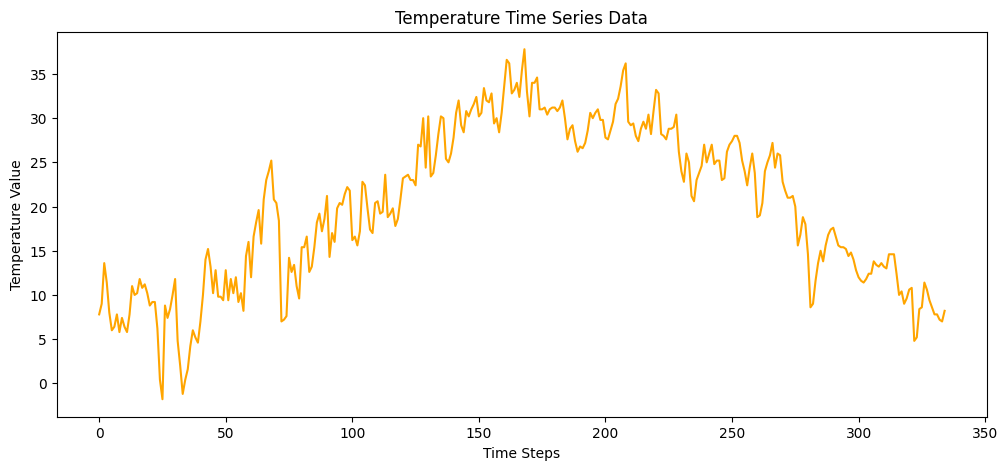

X_temp shape: (321, 12, 1), y_temp shape: (321, 1)
Train samples: 256 | Test samples: 65

آموزش Bidirectional LSTM روی داده‌های دما
تست اولیه Bi-LSTM (قبل از آموزش): 0.050568
Bi-LSTM Epoch  0 | Loss: 0.135558
Bi-LSTM Epoch  2 | Loss: 0.016802
Bi-LSTM Epoch  4 | Loss: 0.014136
Bi-LSTM Epoch  6 | Loss: 0.013727
Bi-LSTM Epoch  8 | Loss: 0.013295

Bi-LSTM Test MSE: 0.025726

آموزش Bidirectional GRU روی داده‌های دما
Bi-GRU  Epoch  0 | Loss: 0.040513
Bi-GRU  Epoch  2 | Loss: 0.010154
Bi-GRU  Epoch  4 | Loss: 0.010102
Bi-GRU  Epoch  6 | Loss: 0.010076
Bi-GRU  Epoch  8 | Loss: 0.010051

Bi-GRU Test MSE: 0.015369

مدل                 Test MSE
Bi-LSTM             0.025726
Bi-GRU              0.015369


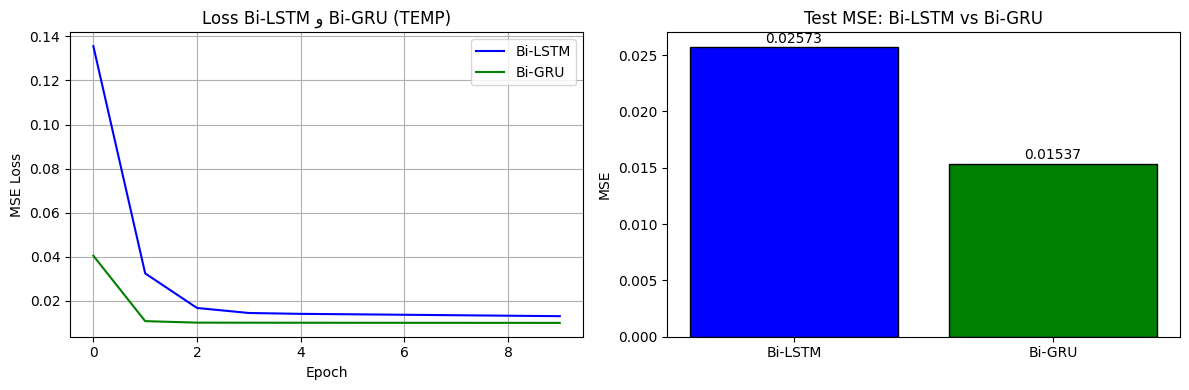

In [35]:
#------------------------------------------------------KASRA ATTAR KASHANI------------------------------------
#---------------------------------------------------------DL_HW2--------------------------------------------------------
#--------------------------------------بخش چهارم - Bidirectional LSTM و GRU از صفر با آموزش --------------------------

# ============================================================
# بارگذاری و پیش‌پردازش دیتاست دما
# ============================================================
file_path = r"C:\Users\USER\Desktop\DL_HW2\HW2\dataset\Temperature Dataset.xlsx"
df_temp = pd.read_excel(file_path)

df_temp_numeric = df_temp.select_dtypes(include=['float64', 'int64'])
temp_data = df_temp_numeric.iloc[:, -1].values.reshape(-1, 1)

plt.figure(figsize=(12, 5))
plt.plot(temp_data[:500], color='orange')
plt.title("Temperature Time Series Data")
plt.xlabel("Time Steps")
plt.ylabel("Temperature Value")
plt.show()

scaler_temp = MinMaxScaler(feature_range=(0, 1))
scaled_temp = scaler_temp.fit_transform(temp_data)

def create_time_series_dataset(data, time_steps=12, lookahead_step=3):
    X, y = [], []
    for i in range(len(data) - time_steps - lookahead_step + 1):
        X.append(data[i : i + time_steps])
        y.append(data[i + time_steps + lookahead_step - 1])
    return np.array(X), np.array(y)

X_temp, y_temp = create_time_series_dataset(scaled_temp, time_steps=12, lookahead_step=3)
print(f"X_temp shape: {X_temp.shape}, y_temp shape: {y_temp.shape}")

# ============================================================
# کلاس Bidirectional LSTM از صفر
# ============================================================
class BidirectionalLSTM:
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size
        scale = 0.1
        # وزن‌های جهت رو به جلو (Forward)
        self.Wf_fwd = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wi_fwd = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wc_fwd = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wo_fwd = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.bf_fwd = np.zeros((hidden_size, 1))
        self.bi_fwd = np.zeros((hidden_size, 1))
        self.bc_fwd = np.zeros((hidden_size, 1))
        self.bo_fwd = np.zeros((hidden_size, 1))
        # وزن‌های جهت عقب (Backward)
        self.Wf_bwd = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wi_bwd = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wc_bwd = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wo_bwd = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.bf_bwd = np.zeros((hidden_size, 1))
        self.bi_bwd = np.zeros((hidden_size, 1))
        self.bc_bwd = np.zeros((hidden_size, 1))
        self.bo_bwd = np.zeros((hidden_size, 1))
        # لایه FC — ورودی: concat تمام hidden stateها در هر دو جهت
        # اندازه: hidden_size * 2 (fwd+bwd) * time_steps (12)
        self.W_fc = np.random.randn(1, hidden_size * 2 * 12) * scale
        self.b_fc = np.zeros((1, 1))

    def _lstm_pass(self, x_seq, Wf, Wi, Wc, Wo, bf, bi, bc, bo):
        """یک پاس LSTM در یک جهت"""
        h = np.zeros((self.hidden_size, 1))
        c = np.zeros((self.hidden_size, 1))
        h_seq = []
        for t in range(x_seq.shape[0]):
            xt = x_seq[t].reshape(-1, 1)
            concat = np.vstack((h, xt))
            f   = sigmoid(np.dot(Wf, concat) + bf)
            i_g = sigmoid(np.dot(Wi, concat) + bi)
            c_tilde = tanh(np.dot(Wc, concat) + bc)
            o   = sigmoid(np.dot(Wo, concat) + bo)
            c   = f * c + i_g * c_tilde
            h   = o * tanh(c)
            h_seq.append(h)
        return h_seq

    def forward(self, x_seq):
        """
        Forward Pass:
        توالی را در دو جهت پردازش می‌کند و خروجی همه گام‌های زمانی
        را concat کرده به FC می‌دهد (طبق صورت سوال)
        """
        h_fwd = self._lstm_pass(x_seq,
                                self.Wf_fwd, self.Wi_fwd, self.Wc_fwd, self.Wo_fwd,
                                self.bf_fwd, self.bi_fwd, self.bc_fwd, self.bo_fwd)
        h_bwd = self._lstm_pass(x_seq[::-1],
                                self.Wf_bwd, self.Wi_bwd, self.Wc_bwd, self.Wo_bwd,
                                self.bf_bwd, self.bi_bwd, self.bc_bwd, self.bo_bwd)
        h_bwd = h_bwd[::-1]  # align با forward

        # concat همه hidden stateها → FC
        combined      = np.concatenate([np.vstack(h_fwd), np.vstack(h_bwd)], axis=1)
        combined_flat = combined.flatten().reshape(-1, 1)

        y_pred = np.dot(self.W_fc, combined_flat) + self.b_fc
        return y_pred.item()

    def train_step(self, x_seq, y_true, lr=0.001):
        """یک گام SGD — گرادیان analytical برای FC"""
        y_pred = self.forward(x_seq)
        error  = y_pred - y_true
        loss   = error ** 2

        # محاسبه combined_flat برای گرادیان W_fc
        h_fwd = self._lstm_pass(x_seq,
                                self.Wf_fwd, self.Wi_fwd, self.Wc_fwd, self.Wo_fwd,
                                self.bf_fwd, self.bi_fwd, self.bc_fwd, self.bo_fwd)
        h_bwd = self._lstm_pass(x_seq[::-1],
                                self.Wf_bwd, self.Wi_bwd, self.Wc_bwd, self.Wo_bwd,
                                self.bf_bwd, self.bi_bwd, self.bc_bwd, self.bo_bwd)
        h_bwd = h_bwd[::-1]

        combined      = np.concatenate([np.vstack(h_fwd), np.vstack(h_bwd)], axis=1)
        combined_flat = combined.flatten().reshape(-1, 1)

        # dL/dW_fc = 2 * error * combined_flat.T
        dW_fc = 2 * error * combined_flat.T
        db_fc = 2 * error

        self.W_fc -= lr * dW_fc
        self.b_fc -= lr * db_fc
        return loss


# ============================================================
# کلاس Bidirectional GRU از صفر
# ============================================================
class BidirectionalGRU:
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size
        scale = 0.1
        # جهت رو به جلو
        self.Wz_fwd = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wr_fwd = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wh_fwd = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.bz_fwd = np.zeros((hidden_size, 1))
        self.br_fwd = np.zeros((hidden_size, 1))
        self.bh_fwd = np.zeros((hidden_size, 1))
        # جهت عقب
        self.Wz_bwd = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wr_bwd = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wh_bwd = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.bz_bwd = np.zeros((hidden_size, 1))
        self.br_bwd = np.zeros((hidden_size, 1))
        self.bh_bwd = np.zeros((hidden_size, 1))
        # لایه FC
        self.W_fc = np.random.randn(1, hidden_size * 2 * 12) * scale
        self.b_fc = np.zeros((1, 1))

    def _gru_pass(self, x_seq, Wz, Wr, Wh, bz, br, bh):
        h = np.zeros((self.hidden_size, 1))
        h_seq = []
        for t in range(x_seq.shape[0]):
            xt     = x_seq[t].reshape(-1, 1)
            concat = np.vstack((h, xt))
            z      = sigmoid(np.dot(Wz, concat) + bz)
            r      = sigmoid(np.dot(Wr, concat) + br)
            h_tilde = tanh(np.dot(Wh, np.vstack((r * h, xt))) + bh)
            h      = (1 - z) * h + z * h_tilde
            h_seq.append(h)
        return h_seq

    def forward(self, x_seq):
        h_fwd = self._gru_pass(x_seq,
                               self.Wz_fwd, self.Wr_fwd, self.Wh_fwd,
                               self.bz_fwd, self.br_fwd, self.bh_fwd)
        h_bwd = self._gru_pass(x_seq[::-1],
                               self.Wz_bwd, self.Wr_bwd, self.Wh_bwd,
                               self.bz_bwd, self.br_bwd, self.bh_bwd)
        h_bwd = h_bwd[::-1]

        combined      = np.concatenate([np.vstack(h_fwd), np.vstack(h_bwd)], axis=1)
        combined_flat = combined.flatten().reshape(-1, 1)
        y_pred = np.dot(self.W_fc, combined_flat) + self.b_fc
        return y_pred.item()

    def train_step(self, x_seq, y_true, lr=0.001):
        y_pred = self.forward(x_seq)
        error  = y_pred - y_true
        loss   = error ** 2

        h_fwd = self._gru_pass(x_seq,
                               self.Wz_fwd, self.Wr_fwd, self.Wh_fwd,
                               self.bz_fwd, self.br_fwd, self.bh_fwd)
        h_bwd = self._gru_pass(x_seq[::-1],
                               self.Wz_bwd, self.Wr_bwd, self.Wh_bwd,
                               self.bz_bwd, self.br_bwd, self.bh_bwd)
        h_bwd = h_bwd[::-1]

        combined      = np.concatenate([np.vstack(h_fwd), np.vstack(h_bwd)], axis=1)
        combined_flat = combined.flatten().reshape(-1, 1)

        dW_fc = 2 * error * combined_flat.T
        db_fc = 2 * error

        self.W_fc -= lr * dW_fc
        self.b_fc -= lr * db_fc
        return loss


# ============================================================
# آموزش و مقایسه Bi-LSTM و Bi-GRU روی داده‌های دما
# ============================================================
split_idx_temp = int(len(X_temp) * 0.8)
X_train_temp = X_temp[:split_idx_temp]; y_train_temp = y_temp[:split_idx_temp]
X_test_temp  = X_temp[split_idx_temp:]; y_test_temp  = y_temp[split_idx_temp:]

print(f"Train samples: {len(X_train_temp)} | Test samples: {len(X_test_temp)}")

input_dim  = X_temp.shape[2]
epochs_bi  = 10
lr_bi      = 0.001
max_train  = 500  # برای سرعت — اگر زمان کافی داری عدد را بزرگ‌تر کن

# ---- Bi-LSTM ----
print("\n" + "=" * 60)
print("آموزش Bidirectional LSTM روی داده‌های دما")
print("=" * 60)

bi_lstm_model = BidirectionalLSTM(input_dim, 32)
print(f"تست اولیه Bi-LSTM (قبل از آموزش): {bi_lstm_model.forward(X_temp[0]):.6f}")

bilstm_losses = []
for epoch in range(epochs_bi):
    total_loss = 0.0
    for i in range(min(max_train, len(X_train_temp))):
        loss = bi_lstm_model.train_step(
            X_train_temp[i], y_train_temp[i].item(), lr=lr_bi)
        total_loss += loss
    avg = total_loss / min(max_train, len(X_train_temp))
    bilstm_losses.append(avg)
    if epoch % 2 == 0:
        print(f"Bi-LSTM Epoch {epoch:2d} | Loss: {avg:.6f}")

bilstm_preds = [bi_lstm_model.forward(X_test_temp[i]) for i in range(len(X_test_temp))]
bilstm_mse   = np.mean((np.array(bilstm_preds) - y_test_temp.flatten()) ** 2)
print(f"\nBi-LSTM Test MSE: {bilstm_mse:.6f}")

# ---- Bi-GRU ----
print("\n" + "=" * 60)
print("آموزش Bidirectional GRU روی داده‌های دما")
print("=" * 60)

bi_gru_model = BidirectionalGRU(input_dim, 32)

bigru_losses = []
for epoch in range(epochs_bi):
    total_loss = 0.0
    for i in range(min(max_train, len(X_train_temp))):
        loss = bi_gru_model.train_step(
            X_train_temp[i], y_train_temp[i].item(), lr=lr_bi)
        total_loss += loss
    avg = total_loss / min(max_train, len(X_train_temp))
    bigru_losses.append(avg)
    if epoch % 2 == 0:
        print(f"Bi-GRU  Epoch {epoch:2d} | Loss: {avg:.6f}")

bigru_preds = [bi_gru_model.forward(X_test_temp[i]) for i in range(len(X_test_temp))]
bigru_mse   = np.mean((np.array(bigru_preds) - y_test_temp.flatten()) ** 2)
print(f"\nBi-GRU Test MSE: {bigru_mse:.6f}")

# ---- نتایج و نمودار ----
print("\n" + "=" * 60)
print(f"{'مدل':<15} {'Test MSE':>12}")
print("=" * 60)
print(f"{'Bi-LSTM':<15} {bilstm_mse:>12.6f}")
print(f"{'Bi-GRU':<15} {bigru_mse:>12.6f}")
print("=" * 60)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(bilstm_losses, label='Bi-LSTM', color='blue')
plt.plot(bigru_losses,  label='Bi-GRU',  color='green')
plt.title('Loss Bi-LSTM و Bi-GRU (TEMP)')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
bars = plt.bar(['Bi-LSTM', 'Bi-GRU'], [bilstm_mse, bigru_mse],
               color=['blue', 'green'], edgecolor='black')
for bar, val in zip(bars, [bilstm_mse, bigru_mse]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.0001,
             f'{val:.5f}', ha='center', va='bottom')
plt.title('Test MSE: Bi-LSTM vs Bi-GRU')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
C:\Users\USER\AppData\Local\Temp\ipykernel_22892\1474539756.py:17: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Synthetic Sequence: $y(t) = \sin(t) + 0.5\cos(2t)$")


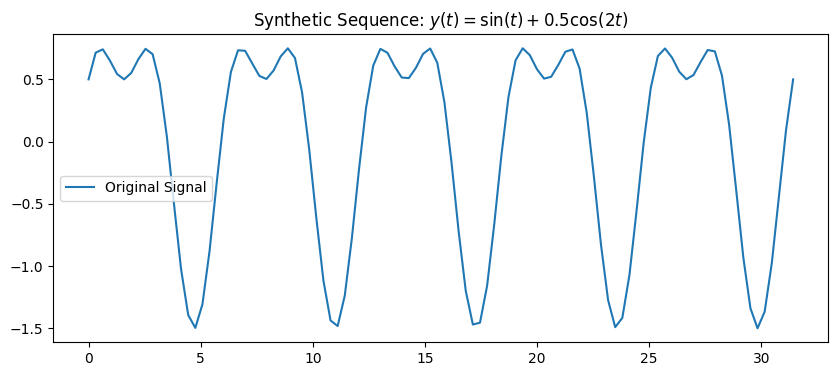

C:\Users\USER\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 851ms/step


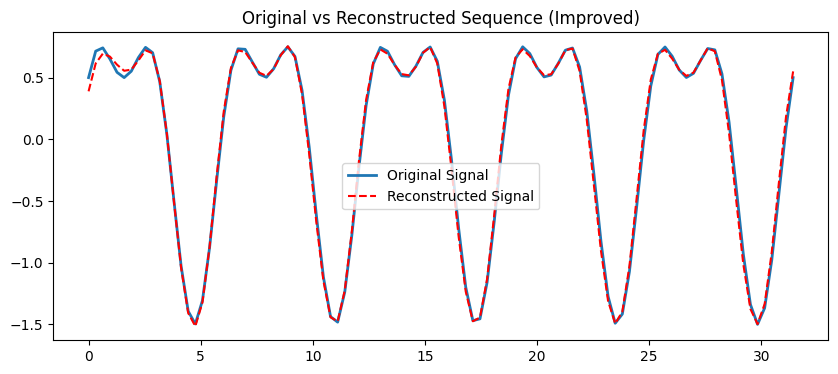

In [28]:
#------------------------------------------------------KASRA ATTAR KASHANI------------------------------------
#---------------------------------------------------------DL_HW2--------------------------------------------------------
#--------------------------------------بخش پنجم ------------------------------------------------------------------------

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed

# تولید داده‌ها
t = np.linspace(0, 10 * np.pi, 100) # بازه مناسب
y = np.sin(t) + 0.5 * np.cos(2*t)

# نمایش سیگنال اصلی
plt.figure(figsize=(10, 4))
plt.plot(t, y, label='Original Signal')
plt.legend()
plt.title("Synthetic Sequence: $y(t) = \sin(t) + 0.5\cos(2t)$")
plt.show()

# LSTM Autoencoder (شکل: Samples, TimeSteps, Features)
sequence = y.reshape(1, 100, 1)

# طراحی مدل
model = Sequential()

model.add(LSTM(64, activation='tanh', input_shape=(100, 1))) 
model.add(RepeatVector(100))
model.add(LSTM(64, activation='tanh', return_sequences=True))
model.add(TimeDistributed(Dense(1)))

model.compile(optimizer='adam', loss='mse')

# افزایش تعداد اپوک‌ها برای یادگیری بهتر شکل موج
history = model.fit(sequence, sequence, epochs=500, verbose=0) 

# بازسازی و مقایسه
reconstructed_seq = model.predict(sequence)
reconstructed_seq = reconstructed_seq.flatten()

plt.figure(figsize=(10, 4))
plt.plot(t, y, label='Original Signal', linewidth=2)
plt.plot(t, reconstructed_seq, label='Reconstructed Signal', linestyle='--', color='red')
plt.legend()
plt.title("Original vs Reconstructed Sequence (Improved)")
plt.show()

ECG dataset shape: (3748, 1)


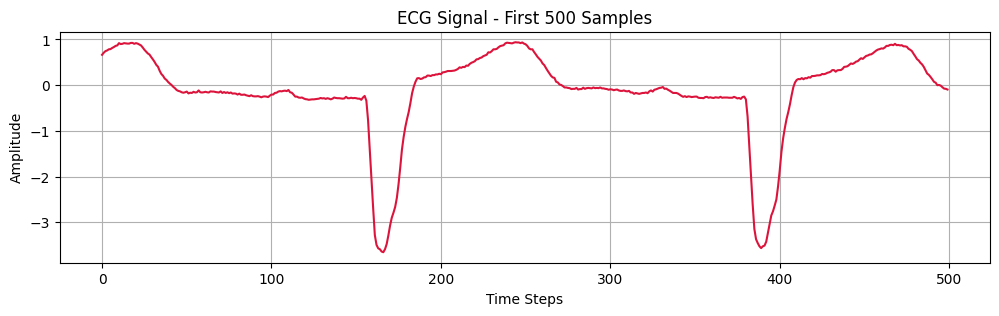

X_ecg shape: (3737, 10, 1), y_ecg shape: (3737, 1)
Train: 2989 samples | Test: 748 samples

در حال آموزش مدل Ensemble (LSTM + GRU) روی ECG...
Epoch  0 | Train Loss (MSE): 0.021590 | alpha=0.6495 | beta=0.7149
Epoch 10 | Train Loss (MSE): 0.003687 | alpha=0.6092 | beta=1.0606
Epoch 20 | Train Loss (MSE): 0.003382 | alpha=0.5717 | beta=1.1408
Epoch 30 | Train Loss (MSE): 0.003036 | alpha=0.5301 | beta=1.2637
Epoch 40 | Train Loss (MSE): 0.002631 | alpha=0.4872 | beta=1.4321

آموزش به پایان رسید.
وزن نهایی آلفا: 0.4502, وزن نهایی بتا: 1.6168
Test MSE: 0.008749


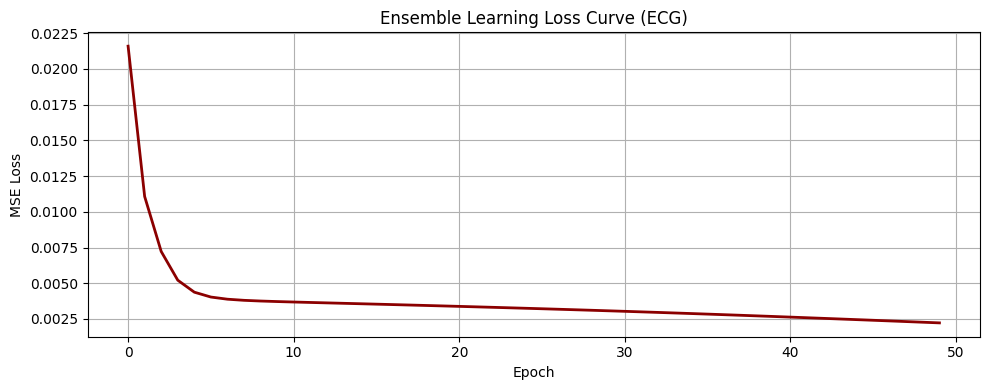

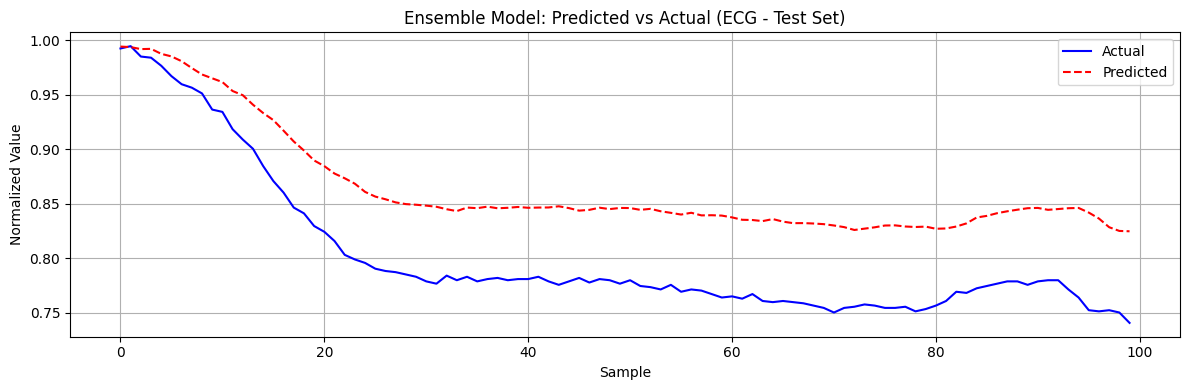

In [34]:
#------------------------------------------------------KASRA ATTAR KASHANI------------------------------------
#---------------------------------------------------------DL_HW2--------------------------------------------------------
#--------------------------------------بخش ششم - Ensemble Learning (LSTM + GRU) روی ECG ------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
def tanh(x): return np.tanh(x)

# ============================================================
# بارگذاری و پیش‌پردازش دیتاست ECG
# ============================================================
ecg_file = r"C:\Users\USER\Desktop\DL_HW2\HW2\dataset\ECG Datasets.xlsx"  # ← مسیر خودت را بذار
df_ecg = pd.read_excel(ecg_file, header=None)
print("ECG dataset shape:", df_ecg.shape)

ecg_raw = df_ecg.iloc[:, 0].values.reshape(-1, 1)

plt.figure(figsize=(12, 3))
plt.plot(ecg_raw[:500], color='crimson')
plt.title("ECG Signal - First 500 Samples")
plt.xlabel("Time Steps"); plt.ylabel("Amplitude")
plt.grid(True); plt.show()

# نرمال‌سازی
scaler_ecg = MinMaxScaler(feature_range=(0, 1))
scaled_ecg = scaler_ecg.fit_transform(ecg_raw)

# ساخت دیتاست: 10 گام ورودی، پیش‌بینی گام دوم بعدی (lookahead=2)
def create_sequences(data, time_steps, lookahead):
    X, y = [], []
    for i in range(len(data) - time_steps - lookahead + 1):
        X.append(data[i : i + time_steps])
        y.append(data[i + time_steps + lookahead - 1])
    return np.array(X), np.array(y)

time_steps_ecg = 10
lookahead_ecg  = 2
X_ecg, y_ecg = create_sequences(scaled_ecg, time_steps_ecg, lookahead_ecg)
print(f"X_ecg shape: {X_ecg.shape}, y_ecg shape: {y_ecg.shape}")

# ============================================================
# کلاس LSTM از صفر
# ============================================================
class SimpleLSTMFromScratch:
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size
        scale = 0.1
        self.Wf = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wi = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wc = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wo = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.bf = np.zeros((hidden_size, 1))
        self.bi = np.zeros((hidden_size, 1))
        self.bc = np.zeros((hidden_size, 1))
        self.bo = np.zeros((hidden_size, 1))

    def forward_step(self, xt, h_prev, c_prev):
        concat  = np.vstack((h_prev, xt))
        f       = sigmoid(np.dot(self.Wf, concat) + self.bf)
        i_g     = sigmoid(np.dot(self.Wi, concat) + self.bi)
        c_tilde = tanh(np.dot(self.Wc, concat)    + self.bc)
        o       = sigmoid(np.dot(self.Wo, concat) + self.bo)
        c_next  = f * c_prev + i_g * c_tilde
        h_next  = o * tanh(c_next)
        return h_next, c_next

    def forward_sequence(self, x_seq):
        """کل توالی را پردازش می‌کند — آخرین hidden state برگردانده می‌شود"""
        h = np.zeros((self.hidden_size, 1))
        c = np.zeros((self.hidden_size, 1))
        for t in range(x_seq.shape[0]):
            h, c = self.forward_step(x_seq[t].reshape(-1, 1), h, c)
        return h

# ============================================================
# کلاس GRU از صفر
# ============================================================
class SimpleGRUFromScratch:
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size
        scale = 0.1
        self.Wz = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wr = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.Wh = np.random.randn(hidden_size, hidden_size + input_size) * scale
        self.bz = np.zeros((hidden_size, 1))
        self.br = np.zeros((hidden_size, 1))
        self.bh = np.zeros((hidden_size, 1))

    def forward_sequence(self, x_seq):
        """کل توالی را پردازش می‌کند — آخرین hidden state برگردانده می‌شود"""
        h = np.zeros((self.hidden_size, 1))
        for t in range(x_seq.shape[0]):
            xt     = x_seq[t].reshape(-1, 1)
            concat = np.vstack((h, xt))
            z      = sigmoid(np.dot(self.Wz, concat) + self.bz)
            r      = sigmoid(np.dot(self.Wr, concat) + self.br)
            h_tilde = tanh(np.dot(self.Wh, np.vstack((r * h, xt))) + self.bh)
            h      = (1 - z) * h + z * h_tilde
        return h

# ============================================================
# کلاس Ensemble (LSTM + GRU با وزن‌دهی آموخته‌شده α و β)
# ============================================================
class EnsembleRNN:
    def __init__(self, input_size, hidden_size):
        self.lstm  = SimpleLSTMFromScratch(input_size, hidden_size)
        self.gru   = SimpleGRUFromScratch(input_size, hidden_size)

        # پارامترهای وزن‌دهی که آموزش می‌بینند
        self.alpha = np.float64(0.5)
        self.beta  = np.float64(0.5)

        # لایه Dense مشترک
        self.W_dense = np.random.randn(1, hidden_size) * 0.1
        self.b_dense = np.zeros((1, 1))

    def forward(self, x_seq):
        """
        Forward Pass:
          h_lstm  = آخرین hidden state LSTM (کل sequence)
          h_gru   = آخرین hidden state GRU  (کل sequence)
          y = alpha * Dense(h_lstm) + beta * Dense(h_gru)
        """
        h_lstm = self.lstm.forward_sequence(x_seq)
        h_gru  = self.gru.forward_sequence(x_seq)

        out_lstm = (np.dot(self.W_dense, h_lstm) + self.b_dense).item()
        out_gru  = (np.dot(self.W_dense, h_gru)  + self.b_dense).item()

        y_pred = self.alpha * out_lstm + self.beta * out_gru
        return y_pred, out_lstm, out_gru, h_lstm, h_gru

    def train_step(self, x_seq, y_true, lr=0.01):
        """
        Backpropagation با SGD:
          گرادیان نسبت به alpha، beta، W_dense و b_dense محاسبه می‌شود
        """
        y_pred, out_lstm, out_gru, h_lstm, h_gru = self.forward(x_seq)
        y_true_val = float(y_true.item())

        error  = y_pred - y_true_val
        dL_dy  = 2.0 * error          # مشتق MSE

        # گرادیان alpha و beta
        d_alpha = dL_dy * out_lstm
        d_beta  = dL_dy * out_gru

        # گرادیان W_dense و b_dense (از هر دو مسیر)
        d_out_lstm = dL_dy * self.alpha
        d_out_gru  = dL_dy * self.beta
        dW_dense   = d_out_lstm * h_lstm.T + d_out_gru * h_gru.T
        db_dense   = np.array([[d_out_lstm + d_out_gru]])

        # بروزرسانی SGD
        self.alpha   -= lr * d_alpha
        self.beta    -= lr * d_beta
        self.W_dense -= lr * dW_dense
        self.b_dense -= lr * db_dense

        return error ** 2   # MSE loss

# ============================================================
# تقسیم داده و حلقه آموزش
# ============================================================
split_idx_ecg = int(len(X_ecg) * 0.8)
X_train_ecg = X_ecg[:split_idx_ecg];  y_train_ecg = y_ecg[:split_idx_ecg]
X_test_ecg  = X_ecg[split_idx_ecg:];  y_test_ecg  = y_ecg[split_idx_ecg:]

print(f"Train: {len(X_train_ecg)} samples | Test: {len(X_test_ecg)} samples")

ensemble = EnsembleRNN(input_size=X_ecg.shape[2], hidden_size=32)
epochs = 50
lr     = 0.01

print("\nدر حال آموزش مدل Ensemble (LSTM + GRU) روی ECG...")
print("=" * 55)

epoch_losses = []
for epoch in range(epochs):
    total_loss = 0.0
    for i in range(len(X_train_ecg)):
        loss = ensemble.train_step(X_train_ecg[i], y_train_ecg[i], lr=lr)
        total_loss += loss
    avg_loss = total_loss / len(X_train_ecg)
    epoch_losses.append(avg_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:2d} | Train Loss (MSE): {avg_loss:.6f} "
              f"| alpha={ensemble.alpha:.4f} | beta={ensemble.beta:.4f}")

print("\nآموزش به پایان رسید.")
print(f"وزن نهایی آلفا: {ensemble.alpha:.4f}, وزن نهایی بتا: {ensemble.beta:.4f}")

# MSE روی test set
test_preds = [ensemble.forward(X_test_ecg[i])[0] for i in range(len(X_test_ecg))]
test_mse   = np.mean((np.array(test_preds) - y_test_ecg.flatten()) ** 2)
print(f"Test MSE: {test_mse:.6f}")

# ============================================================
# نمودارها
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(epoch_losses, color='darkred', linewidth=2)
plt.title('Ensemble Learning Loss Curve (ECG)')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.grid(True); plt.tight_layout(); plt.show()

n_show = min(100, len(X_test_ecg))
plt.figure(figsize=(12, 4))
plt.plot(y_test_ecg[:n_show],  label='Actual',    color='blue')
plt.plot(test_preds[:n_show],  label='Predicted', color='red', linestyle='--')
plt.title('Ensemble Model: Predicted vs Actual (ECG - Test Set)')
plt.xlabel('Sample'); plt.ylabel('Normalized Value')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()